# Bias Detection & Algorithmic Fairness Audit

**Role:** Data Scientist  
**Project:** NovaCred Loan Approval System  
**Objective:** To audit the cleaned dataset for direct and indirect discrimination, ensuring compliance with the '80% Rule' and identifying potential proxy variables.

In [7]:
#Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from fairlearn.metrics import demographic_parity_difference

print("All Libraries sucessfully loaded.")

#Visualization settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = [10, 6]

print("Environment ready for audit.")

All Libraries sucessfully loaded.
Environment ready for audit.


## 1. Data Loading

In [2]:
#Load the Cleaned Dataset

df = pd.read_csv("cleaned_credit_data-2.csv")

#Display the first 5 rows to confirm it loaded correctly
df.head()

,_id,processing_timestamp,applicant_info.full_name,applicant_info.email,applicant_info.ssn,applicant_info.ip_address,applicant_info.gender,applicant_info.date_of_birth,applicant_info.zip_code,financials.annual_income,...,Fitness,Gambling,Groceries,Healthcare,Insurance,Rent,Shopping,Transportation,Travel,Utilities
0,app_001,NaN,Stephanie Nguyen,stephanie.nguyen47@mail.com,d49cad59b567,10.121.120.213,Female,1986-05-27,90230.0,102000.0,...,576.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,app_002,NaN,Kevin Roberts,kevin.roberts9@protonmail.com,0e1892639ce7,172.19.95.144,Male,1999-08-01,10020.0,41000.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,app_003,NaN,Lisa Gonzalez,lisa.gonzalez51@yahoo.com,5e93b5041cec,172.21.35.195,Female,1982-08-24,90213.0,65000.0,...,0.0,0.0,0.0,450.0,0.0,0.0,0.0,0.0,0.0,0.0
3,app_004,NaN,Karen Nelson,karen.nelson35@outlook.com,3ef30b5e161e,172.31.79.76,Female,1995-02-28,90217.0,69000.0,...,0.0,0.0,810.0,0.0,0.0,0.0,0.0,329.0,0.0,0.0
4,app_005,NaN,Christine Mitchell,christine.mitchell3@outlook.com,8c2a4e7afef6,172.25.44.173,Female,1960-06-19,90296.0,39000.0,...,0.0,0.0,0.0,0.0,585.0,0.0,0.0,0.0,0.0,0.0


## 2. Data Quality Assessment
Before the analysis, we validate the work of the Data Engineering team. A high-quality audit requires zero missing values in protected attributes and a structured format for behavioral data.

In [8]:
#Checking for missing values in critical columns
quality_check = df[['applicant_info.gender', 'decision.loan_approved', 'applicant_info.zip_code']].isna().sum()

print("Quality Audit Results (Missing Values):")
print(quality_check)

print(f"\nTotal clean records: {len(df)}")

#Verifying if spending data was correctly flattened
spending_cols = ['Adult Entertainment', 'Alcohol', 'Dining', 'Education', 'Entertainment', 
                 'Fitness', 'Gambling', 'Groceries', 'Healthcare', 'Insurance', 
                 'Rent', 'Shopping', 'Transportation', 'Travel', 'Utilities']
print(f"Flattened spending features detected: {len(spending_cols)}")

Quality Audit Results (Missing Values):
applicant_info.gender      0
decision.loan_approved     0
applicant_info.zip_code    1
dtype: int64

Total clean records: 500
Flattened spending features detected: 15


## 3. Direct Bias Analysis: The 80% Rule
We use the **Disparate Impact Ratio (DI)** to check for direct discrimination. According to the **Four-Fifths Rule**, if the approval rate of a protected group (Women) is less than 80% of the privileged group (Men), the model is legally considered to have an adverse impact.

In [11]:
#Direct Bias Metrics

#1. Approval Rates
selection_rates = df.groupby("applicant_info.gender")["decision.loan_approved"].mean()
male_rate = selection_rates["Male"]
female_rate = selection_rates["Female"]

#2. Disparate Impact Ratio
di_ratio = female_rate / male_rate

#3. Fairlearn Parity Metric
dp_diff = demographic_parity_difference(
    y_true=df["decision.loan_approved"],
    y_pred=df["decision.loan_approved"], 
    sensitive_features=df["applicant_info.gender"]
)

print(f"Male Approval Rate: {male_rate:.3f}")
print(f"Female Approval Rate: {female_rate:.3f}")
print(f"Disparate Impact Ratio: {di_ratio:.3f}")

if di_ratio < 0.8:
    print("Conclusion: Bias detected (Violates the 80% Rule).")
else:
    print("Conclusion: No direct bias detected (Passes the 80% Rule).")

Male Approval Rate: 0.660
Female Approval Rate: 0.506
Disparate Impact Ratio: 0.767
Conclusion: Bias detected (Violates the 80% Rule).


## 4. Indirect Bias: Geographic Proxy
Even if 'Gender' is removed, the model might use **ZIP Code** as a proxy. We analyze the correlation between the density of female applicants in a neighborhood and the algorithm's approval rate.

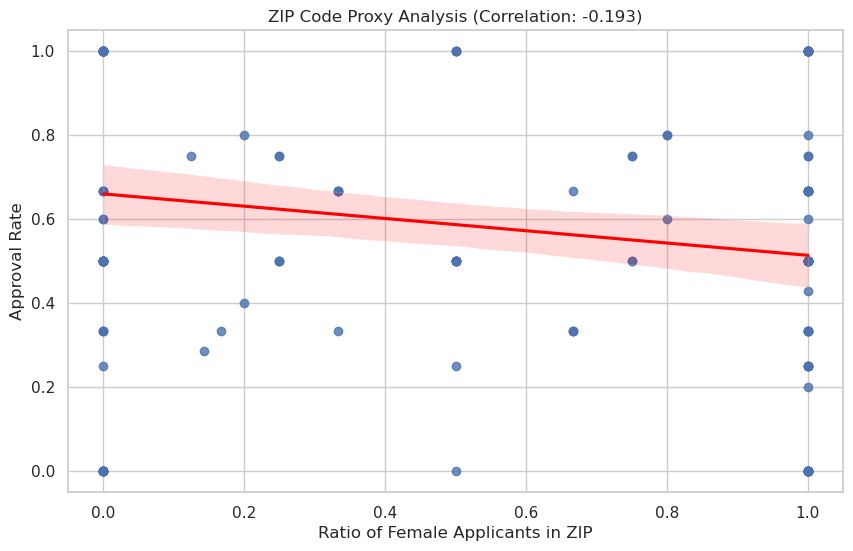

In [13]:
#ZIP Code Proxy Audit

zip_stats = df.groupby("applicant_info.zip_code").agg(
    approval_rate=("decision.loan_approved", "mean"),
    female_ratio=("applicant_info.gender", lambda x: (x == "Female").mean())
).reset_index()

correlation = zip_stats["female_ratio"].corr(zip_stats["approval_rate"])

plt.figure()
sns.regplot(data=zip_stats, x="female_ratio", y="approval_rate", line_kws={"color": "red"})
plt.title(f"ZIP Code Proxy Analysis (Correlation: {correlation:.3f})")
plt.xlabel("Ratio of Female Applicants in ZIP")
plt.ylabel("Approval Rate")
plt.show()

if abs(correlation) > 0.3:
    print(f"ALERT: Strong correlation detected ({correlation:.3f}). ZIP Code is a likely proxy.")

## 5. Indirect Bias: Spending Behavior Proxy
With the flattened spending data, we can now audit 15 different behavioral dimensions. We are looking for categories that are dominated by female applicants but show significantly lower approval rates.

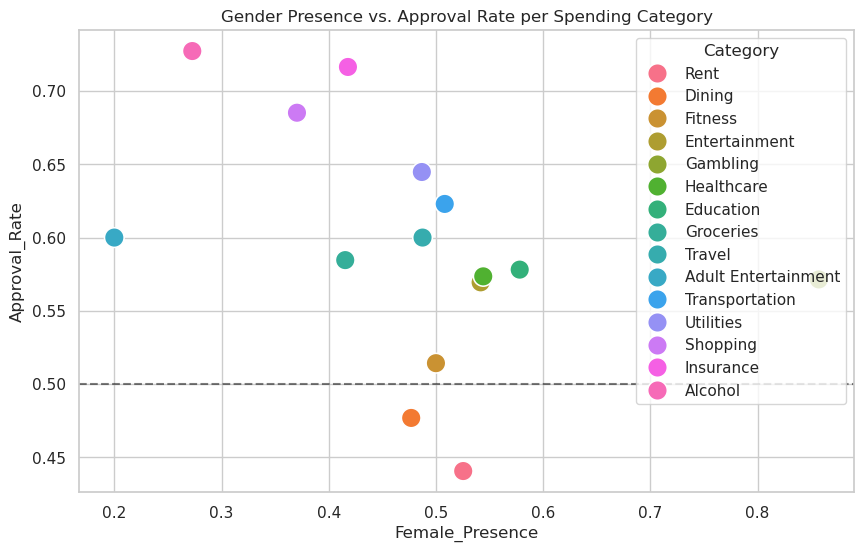

In [15]:
#Behavioral Proxy Audit

category_audit = []
for col in spending_cols:
    active_users = df[df[col] > 0]
    if len(active_users) > 0:
        avg_approval = active_users['decision.loan_approved'].mean()
        female_presence = (active_users['applicant_info.gender'] == 'Female').mean()
        category_audit.append({'Category': col, 'Approval_Rate': avg_approval, 'Female_Presence': female_presence})

audit_results = pd.DataFrame(category_audit).sort_values(by='Approval_Rate')

#Visualization for the presentation
plt.figure()
sns.scatterplot(data=audit_results, x='Female_Presence', y='Approval_Rate', hue='Category', s=200)
plt.axhline(0.5, color='black', linestyle='--', alpha=0.5)
plt.title("Gender Presence vs. Approval Rate per Spending Category")
plt.show()

#Detect Red Flags
red_flags = audit_results[(audit_results['Female_Presence'] > 0.6) & (audit_results['Approval_Rate'] < 0.4)]
if not red_flags.empty:
    print(f"Governance Alert: High-risk proxy categories found: {red_flags['Category'].tolist()}")

## 6. Final Governance Recommendations
Based on this audit, we recommend the following actions to the Governance Board:

1. **Feature Engineering:** Remove "ZIP Code" and identified high-risk spending categories from the training set to prevent proxy discrimination.
2. **Mitigation Strategy:** Implement a 'Fairness Constraint' to re-calibrate the decision threshold for female applicants.
3. **Continuous Monitoring:** Establish a feedback loop between Data Science and Engineering to monitor for "Bias Drift" as new application patterns emerge.